# Problem Set 2: Analysis of racial disparities in felony sentencing, Part 2

Part 2: Investigating Black vs. White sentencing disparities

We're going to investigate different types of disparities in sentencing between Black defendants and White defendants. 
We're focusing on these groups for the purpose of the problem set, but the analysis could be extended to study Hispanic defendants or, in a different jurisdiction, Asian and other minoritized groups.

**Details if interested in digging deeper**: If interested (optional), you can read more technical coverage of how we might (1) measure disparities, and (2) what factors you want to adjust for when deciding whether two defendants are 'similarly situated' but for their race in the following sources:

- [Review of sentencing disparities research](https://www.journals.uchicago.edu/doi/full/10.1086/701505)
- [Discussion of causal model/blinding race at charging stage of the prosecutorial process](https://5harad.com/papers/blind-charging.pdf)
- [Discussion of measuring discrimination in policing that can generalize to the sentencing case](https://www.annualreviews.org/doi/abs/10.1146/annurev-criminol-011518-024731)
- [General discussion of causal challenges in measuring between-group disparities](https://osf.io/preprints/socarxiv/gx4y3/)

**One major caveat**: when investigating whether two similar defendants received different sentences, we're missing one important attribute that influences sentencing: the defendant's criminal history. This influences sentencing both through sentencing guidelines, which can prescribe longer sentences for those who have certain types of prior convictions, and through judicial discretion if judges are more lenient with first-time defendants. The above sources discuss how much we want to "control away" for this prior history, since if we think there are racial biases in which defendants, conditional on *committing* a crime, are arrested and charged, we may not want to adjust for that factor. More discussion [in this article](https://www.themarshallproject.org/2019/12/03/the-growing-racial-disparity-in-prison-time)

## 1.0: (0 points)

First, read in the following dataset (regardless of progress on part one): `sentencing_cleaned.pkl` (if you can't read in the pkl you can read in the .csv format but may need to recast some of the datetime columns)

*Note*: don't worry if there are slight differences in your output from Part One and this dataset/it's not a good use of time to try to reverse engineer Part One answers from this cleaned data.

In [110]:
# setup & get a feel
import pandas as pd
df = pd.read_csv("/Users/vivianaperez/GitHub/QSS20_WI26/problemsets/pset2/pset2_inputdata/sentencing_cleaned.csv")
df.dtypes
df.head()
df.info()

# fix date time
df["sentenceym_derived"] = pd.to_datetime(df["sentenceym_derived"])
df["sentenceym_derived"].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 135165 entries, 0 to 135164
Data columns (total 52 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   CASE_ID                            135165 non-null  int64  
 1   CASE_PARTICIPANT_ID                135165 non-null  int64  
 2   RECEIVED_DATE                      135165 non-null  object 
 3   OFFENSE_CATEGORY                   135165 non-null  object 
 4   PRIMARY_CHARGE_FLAG                135165 non-null  bool   
 5   CHARGE_ID                          135165 non-null  int64  
 6   CHARGE_VERSION_ID                  135165 non-null  int64  
 7   DISPOSITION_CHARGED_OFFENSE_TITLE  135165 non-null  object 
 8   CHARGE_COUNT                       135165 non-null  int64  
 9   DISPOSITION_DATE                   135165 non-null  object 
 10  DISPOSITION_CHARGED_CHAPTER        135165 non-null  object 
 11  DISPOSITION_CHARGED_ACT            1342

/var/folders/k9/0k40031s4q9btj5wvqclnww00000gn/T/ipykernel_38022/1774818705.py:3: DtypeWarning: Columns (10,11,16,25) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/Users/vivianaperez/GitHub/QSS20_WI26/problemsets/pset2/pset2_inputdata/sentencing_cleaned.csv")


## 1.1: Investigating one type of between-group difference: who reaches the sentencing stage? (5 points)

Tabulate and visualize the proportion of defendants, out of all defendants sentenced in a given month/year, who are Black and who are White (separate proportions)

- Denominator is number of unique cases that month
- Numerator for black defendants is count of is_black_derived
- Numerator for white defendants is count of is_white_derived
- Fraction of each is numerator/denominator

- Print the table
- Create a graph with two lines--- one for Black defendants as fraction of total; another for White defendants. Make sure it includes a legend summarizing which color is for which group, and clean the legend so that it has informative names (e.g., Black or White rather than prop_black or prop_white)
- Use mathematical notation to write out each of the proportions using summation notation in a 1-2 sentence writeup describing trends. What seems to be going on in April and May 2020? 

**Optional challenge**: improve the viz by shading the background of the visualization for months with fewer than 100 cases 

**Optional challenge**: improve the viz by adding a vertical line for 12-01-2016, the month that new State's Attorney Foxx took office 

                    total_cases     Black     White
sentenceym_derived                                 
2012-01-01                 1674  0.677419  0.144564
2012-02-01                 1450  0.648966  0.160690
2012-03-01                 1612  0.638958  0.158189
2012-04-01                 1436  0.696379  0.146936
2012-05-01                 1545  0.695146  0.144337


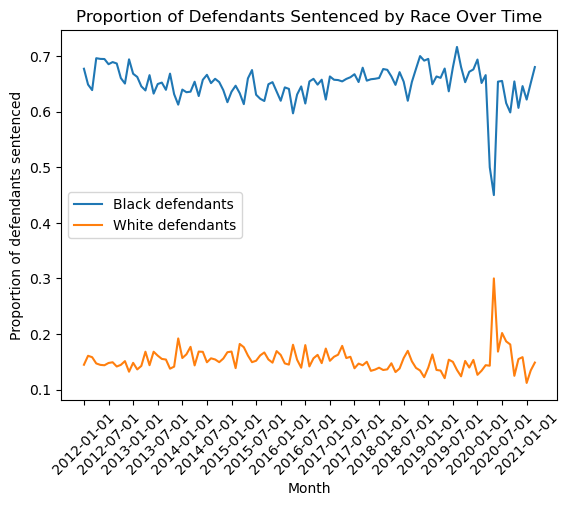

In [111]:
# for me ///
#print(df["is_black_derived"].sum())
#print(df["is_white_derived"].sum())
#df[["CASE_ID", "sentenceym_derived", "is_black_derived", "is_white_derived"]].head()

# denominator (unique cases on a given month) ///
monthly_total = df.groupby("sentenceym_derived")["CASE_ID"].nunique()
#print(monthly_total)

# by race per month ///
monthly_black = df.groupby("sentenceym_derived")["is_black_derived"].sum()
#print(monthly_black.head())
monthly_white = df.groupby("sentenceym_derived")["is_white_derived"].sum()
#print(monthly_white.head())

# table ///
summary = pd.DataFrame({
    "total_cases": monthly_total,
    "Black": monthly_black / monthly_total,
    "White" : monthly_white / monthly_total
})
print(summary.head())

# visualize ///
import matplotlib.pyplot as plt

plt.plot(summary.index.astype(str), summary["Black"], label="Black defendants")
plt.plot(summary.index.astype(str), summary["White"], label="White defendants")

plt.xlabel("Month")
plt.ylabel("Proportion of defendants sentenced")
plt.title("Proportion of Defendants Sentenced by Race Over Time")

plt.legend()

plt.xticks(summary.index.astype(str)[::6], rotation=45)

plt.show()



In [112]:
# The proportion of Black defendants sentenced each month is calculated as the number
#  of Black defendants divided by the total number of unique cases that month and 
# likewise with White defendants. In April and May of 2020, the number of total cases
# drops so much likely because of the COVID breakout causing many couts to be closed.

## 1.2: Investigating the first type of disparity: probation versus incaceration (10 points)

One type of disparity beyond who arrives at the sentencing stage is whether the defendant receives probation or incaceration.

According to the codebook, incarceration is indicated by `COMMITMENT_TYPE` == "Illinois Department of Corrections"

Recreate the previous plot but where the y axis represents the difference between the following proportions (can be either Black - White or White - Black but make sure to label), adding a smoothed line:

- Percent of black defendants who are incarcerated out of all black defendants that month/year 
- Percent of white defendants who are incarcerated out of all white defendants that month/year 

In a markdown cell after, write 1-2 sentences on your observations of trends over time. Do gaps seem to be widening or increasing?

In [ ]:
The graph shows the monthly differnce in incarceration rates between Black and 
White defendants. Positive values represent the months when Black defedants are 
incarcerated at higher rates. Although there is fluxuation, Black defendents
are, on average, more likely to be incarcerated than White defendants. There 
is not overall trend over time, but in 2019 and in 2020, there is are peaks in 
the gap.

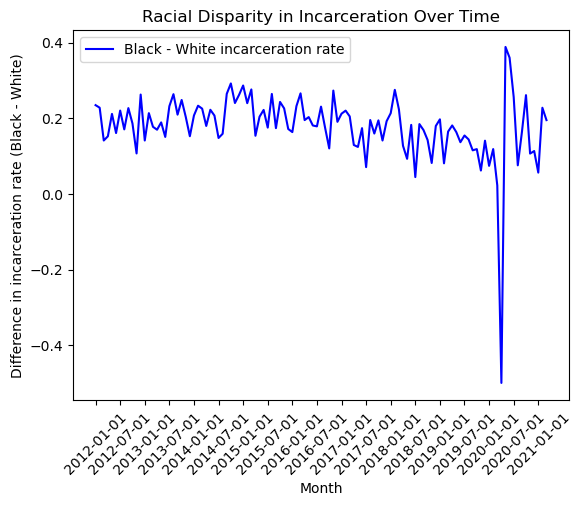

In [113]:
df["is_incarcerated"] = df["COMMITMENT_TYPE"] == "Illinois Department of Corrections"

# black defendants
total_black = df.groupby("sentenceym_derived")["is_black_derived"].sum()
black_incarcerated = df[df["is_black_derived"]].groupby("sentenceym_derived")["is_incarcerated"].sum()
percent_black_incarcerated = black_incarcerated / total_black

# white defendants
total_white = df.groupby("sentenceym_derived")["is_white_derived"].sum()
white_incarcerated = df[df["is_white_derived"]].groupby("sentenceym_derived")["is_incarcerated"].sum()
percent_white_incarcerated = white_incarcerated / total_white

# difference
diff = percent_black_incarcerated - percent_white_incarcerated

# plot
import matplotlib.pyplot as plt
plt.plot(diff.index.astype(str), diff, color="blue", label="Black - White incarceration rate")

plt.xlabel("Month")
plt.ylabel("Difference in incarceration rate (Black - White)")
plt.title("Racial Disparity in Incarceration Over Time")

plt.legend()

plt.xticks(diff.index.astype(str)[::6], rotation=45)

plt.show()


## 1.3: Investigating mechanisms: incaceration rates by charge

Your colleague sees the previous graph and is worried that the gap could be different---either wider or smaller---if you adjust for the fact that prosecutors have discretion in what crimes to charge defendants with. If white defendants are charged with crimes that tend to receive probation rather than incarceration, that could explain some of the gaps.

In the next questions, you'll begin to investigate this.

### 1.3.1: Find the most common offenses (3 points)

First, create a set of 'frequent offenses' that represent (over the entire period) the union of the 10 offenses Black defendant are most likely to be charged with and the 10 offenses white defendants are most likely to be charged with (might be far less than 20 total if there's a lot of overlap in common charges)

Use the `simplified_offense_derived` for this

In [114]:
black_top10 = df[df["is_black_derived"]]["simplified_offense_derived"].value_counts().head(10)
print(black_top10)

white_top10 = df[df["is_white_derived"]]["simplified_offense_derived"].value_counts().head(10)
print(white_top10)

# combine
frequent_offenses = set(black_top10.index).union(set(white_top10.index))
print(frequent_offenses)

simplified_offense_derived
Narcotics                                    29451
UUW - Unlawful Use of Weapon                  9608
Retail Theft                                  6812
Battery                                       4650
Driving With Suspended Or Revoked License     4459
DUI                                           3842
Burglary                                      3798
Theft                                         2623
Vehicle-related                               2400
Robbery                                       2348
Name: count, dtype: int64
simplified_offense_derived
Narcotics                                    4923
Retail Theft                                 2509
DUI                                          1995
Burglary                                     1454
Battery                                      1448
Driving With Suspended Or Revoked License    1160
Theft                                        1095
Residential Burglary                          717
Other Offe

### 1.3.2: Look at incarceration rates (again just whether incarcerated) by race and offense type for these top offenses (3 points)

Print a wide-format version of the resulting table (so each row is an offense type, one col is black incarceration rate for that offense type; another is the white incarceration rate) and interpret. Which offenses show the largest disparities in judges being less likely to sentence White defendants to incarceration/more likely to offer those defendants probation?


In [115]:
df_top = df[df["simplified_offense_derived"].isin(frequent_offenses)]

black_rates = df_top[df_top["is_black_derived"]].groupby("simplified_offense_derived")["is_incarcerated"].mean()
white_rates = df_top[df_top["is_white_derived"]].groupby("simplified_offense_derived")["is_incarcerated"].mean()


incarceration_by_offense = pd.DataFrame({
    "Black": black_rates,
    "White": white_rates
})

# Print the table
print(incarceration_by_offense)


# The table shows inceraration rates by race for the most frequent offenses. The biggest
#disparity for the races was narcotics, UUW, and batter. This suggests that white defednets 
# were more likely to just get probation for these offesnes.

                                              Black     White
simplified_offense_derived                                   
Battery                                    0.509032  0.275552
Burglary                                   0.661927  0.535763
DUI                                        0.404997  0.341855
Driving With Suspended Or Revoked License  0.582193  0.496552
Narcotics                                  0.537876  0.242535
Other Offense                              0.340580  0.230228
Residential Burglary                       0.717791  0.654114
Retail Theft                               0.595713  0.449582
Robbery                                    0.650341  0.589286
Theft                                      0.386961  0.318721
UUW - Unlawful Use of Weapon               0.696191  0.481973
Vehicle-related                            0.553750  0.585635


### 1.3.3: Examine whether this changes pre and post change to charging threshold for retail theft (13 points)

One important question is not only whether there are disparities by offense type but also whether these disparities are changing over time.

The SAO, for instance, announced in December of 2016 that they would no longer default to charging retail thefts of under \$1,000 as felonies. This change might have (1) decreased disparities or (2) increased disparities, depending on the correlation between race/ethnicity and magnitude of goods stolen: [news coverage](https://www.dnainfo.com/chicago/20161215/little-village/kim-foxx-raises-bar-for-retail-theft-felonies/). 

Focusing on `simplified_offense_derived` == "Retail theft." Using a function and/or loop (Dec. 2016 is always excluded as a transition month):

- Compare Black-White disparities before and after the change using a two-month bandwidth (so pre is October and November 2016; post is January and February 2017)

- Compare Black-White disparities before and after the change using a four-month bandwidth (so pre is August- November 2016; post is January - April 2017)

- Compare Black-White disparities using an eight-month bandwidth

- Compare Black-White disparities using a twelve-month bandwidth


------------------ 

- Print a table with the results (any organization is fine as long as it's clear)  

- Create a bar chart where the x axis represents different bandwidths (2, 4, etc); the y axis the size of the Black-White gap in whether the defendant receives incarceration, and for each of the x axis points, you have one shaded bar representing "before" the change, another representing "after" the change (make sure that before is ordered before after and the bandwidths are from smallest to largest)

*Note*: for each of the bandwidths include dates the entire month (e.g., for the first, include not only 02-01-2017 but everything up through 02-28-2017; easiest way is for the subsetting to use the rounded `sentenceym_derived`). Also make sure to only include white or black defendants.


**Extra credit**: because the bandwidths have different sample sizes, a better viz incorporates measures of uncertainty. Add standard errors to the estimates using the formula: $(\dfrac{p(1-p)}{n})^{0.5}$ where $p$ is the gap and $N$ is the number of cases in each bandwidth period 


0.08791208791208793 0.1549491211840888
0.08158756137479534 0.08161468812877265
0.1328998171103435 0.04344978165938862
0.16161847603279728 0.04344978165938862


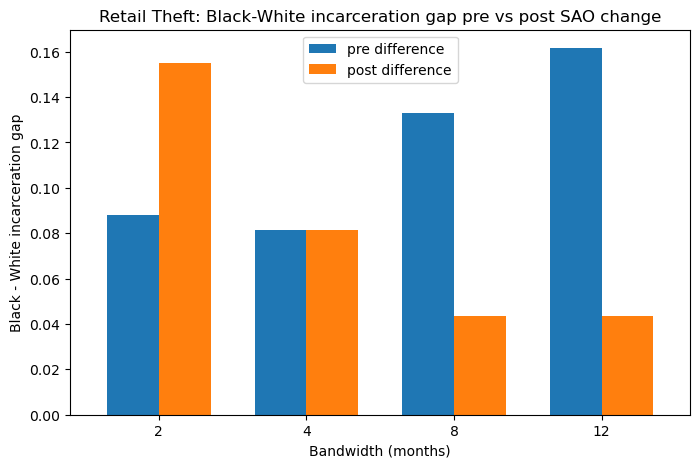

In [116]:
# set up
    # making mini data frame
retail_df = df[
    (df["simplified_offense_derived"] == "Retail Theft") &
    (df["is_black_derived"] | df["is_white_derived"])
]
retail_df.head()

    # function (paramter should include 'n' which represents the period of bandwidth)
def incarceration_gap(df, start_date, end_date):
    black_rate = df[df["is_black_derived"]]["is_incarcerated"].mean()
    white_rate = df[df["is_white_derived"]]["is_incarcerated"].mean()
    return black_rate - white_rate


# two month
pre2 = retail_df[(retail_df["sentenceym_derived"] >= "2016-10-01") & 
    (retail_df["sentenceym_derived"] <= "2016-11-01")]
post2 = retail_df[(retail_df["sentenceym_derived"] >= "2017-01-01") & 
    (retail_df["sentenceym_derived"] <= "2017-02-01")]

gap_pre2 = incarceration_gap(pre2, "2016-10-01", "2016-11-01")
gap_post2 = incarceration_gap(post2, "2017-01-01", "2017-02-01")
print(gap_pre2, gap_post2)


# four month
pre4 = retail_df[(retail_df["sentenceym_derived"] >= "2016-08-01") & 
                 (retail_df["sentenceym_derived"] <= "2016-11-01")]
post4 = retail_df[(retail_df["sentenceym_derived"] >= "2017-01-01") & 
                  (retail_df["sentenceym_derived"] <= "2017-04-01")]

gap_pre4 = incarceration_gap(pre4, "2016-08-01", "2016-11-01")
gap_post4 = incarceration_gap(post4, "2017-01-01", "2017-04-01")
print(gap_pre4, gap_post4)


# eight month
pre8 = retail_df[(retail_df["sentenceym_derived"] >= "2016-04-01") & 
                 (retail_df["sentenceym_derived"] <= "2016-11-01")]
post8 = retail_df[(retail_df["sentenceym_derived"] >= "2017-01-01") & 
                  (retail_df["sentenceym_derived"] <= "2017-08-01")]

gap_pre8 = incarceration_gap(pre8, "2016-04-01", "2016-11-01")
gap_post8 = incarceration_gap(post8, "2017-01-01", "2017-08-01")
print(gap_pre8, gap_post8)


# twelve month
pre12 = retail_df[(retail_df["sentenceym_derived"] >= "2015-12-01") & 
                 (retail_df["sentenceym_derived"] <= "2016-11-01")]
post12 = retail_df[(retail_df["sentenceym_derived"] >= "2017-01-01") & 
                  (retail_df["sentenceym_derived"] <= "2017-08-01")]

gap_pre12 = incarceration_gap(pre12, "2015-12-01", "2016-11-01")
gap_post12 = incarceration_gap(post12, "2017-01-01", "2017-08-01")
print(gap_pre12, gap_post12)


# table 
gaps_df = pd.DataFrame({
    "pre difference": [gap_pre2, gap_pre4, gap_pre8, gap_pre12],
    "post difference": [gap_post2, gap_post4, gap_post8, gap_post12]
}, index=[2,4,8,12])

gaps_df

# bar chart
gaps_df.plot(kind='bar', figsize=(8,5), width=0.7)
plt.ylabel("Black - White incarceration gap")
plt.xlabel("Bandwidth (months)")
plt.title("Retail Theft: Black-White incarceration gap pre vs post SAO change")
plt.xticks(rotation=0)  # keep x labels readable
plt.legend(title="")
plt.show()

### 1.3.3.1: Interpret the results (2 points)

Write a two-sentence interpretation of the results. What might this show about how people on both sides of the issue---those who argued that the retail theft policy change would narrow disparities; those who argued that the change may widen disparities--could support their claims? 

In [117]:
#The difference in incarceration after the change diminished continually. the average
#over the last several month prior to the change, the differnce was increasing, while 
#after the change, the gap began decreasing continually. the changed dimished the dispartity
 #overall.